In [25]:
import networkx as nx
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import math

random.seed(42)
np.random.seed(42)

# 1. Node positions
pos = {
    0:  (0, 2),
    1:  (1, 3),
    2:  (1, 1),
    3:  (2, 0),
    4:  (2, 4),
    5:  (3, 2.5),
    6:  (3, 0.5),
    7:  (4, -0.5),
    8:  (4, 4),
    9:  (5, 2.5),
    10: (5, 0.5),
    11: (6, -0.5),
    12: (6, 3.5),
    13: (7, 1.5),
    14: (8, 1),
}

# 2. Node connectivity
connections = [
    (0, 1), (1, 0), (0, 2), (2, 0), (0, 3), (3, 0),
    (1, 2), (1, 4), (4, 1),
    (2, 3), (3, 2), (2, 5), (5, 2), (2, 6), (6, 2),
    (3, 6), (6, 3), (3, 7), (7, 3),
    (4, 5), (5, 4), (4, 8), (8, 4),
    (5, 6), (6, 5), (5, 8), (8, 5), (5, 9), (9, 5),
    (6, 7), (7, 6), (6, 9), (9, 6), (6, 10), (10, 6),
    (7, 10), (10, 7), (7, 11), (11, 7),
    (8, 9), (8, 12), (12, 8),
    (9, 10), (10, 9), (9, 12), (12, 9), (9, 13), (13, 9),
    (10, 11), (11, 10), (10, 13), (13, 10),
    (11, 13), (13, 11), (11, 14), (14, 11),
    (12, 13), (13, 12),
    (13, 14), (14, 13),
]


# 3. Build the graph
G = nx.DiGraph()
G.add_nodes_from(pos.keys())

for u, v in connections:
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    dist = math.dist((x1, y1), (x2, y2))  # weight = Euclidean distance between nodes
    G.add_edge(u, v, weight=round(dist, 2))

num_nodes = G.number_of_nodes()
print(f"Graph built: {num_nodes} nodes, {G.number_of_edges()} edges")
for u, v, d in G.edges(data=True):
    print(f"  {u} -> {v}: weight={d['weight']}")

# Sequential goals
target_1 = 11
target_2 = 8
num_goals = 2

# 4. Q-Network
# 4.1. Declaration
class QNetwork(nn.Module):
    def __init__(self, num_nodes, num_goals):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_nodes + num_goals, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, num_nodes)
        )

    def forward(self, x):
        return self.fc(x)

# 4.2. Processing current state — now encodes the ACTUAL current target node
def state_to_tensor(node, current_target, num_nodes):
    node_vec = np.zeros(num_nodes, dtype=np.float32)
    node_vec[node] = 1.0
    target_vec = np.zeros(num_nodes, dtype=np.float32)
    target_vec[current_target] = 1.0
    vec = np.concatenate([node_vec, target_vec])
    return torch.tensor(vec).unsqueeze(0)

class QNetwork(nn.Module):
    def __init__(self, num_nodes):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_nodes * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, num_nodes)
        )
    def forward(self, x):
        return self.fc(x)

model = QNetwork(num_nodes)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

gamma = 0.9
epsilon = 0.3

num_episodes = 1500
for episode in range(num_episodes):
    # Randomize which goal is pursued first, each episode
    goal_a, goal_b = random.sample([target_1, target_2], 2)

    current_node = 0
    current_target = goal_a
    done = False
    steps = 0

    while not done and steps < 50:
        neighbors = list(G.successors(current_node))
        if not neighbors:
            break

        state_tensor = state_to_tensor(current_node, current_target, num_nodes)

        if random.random() < epsilon:
            next_node = random.choice(neighbors)
        else:
            with torch.no_grad():
                q_values = model(state_tensor)[0]
                neighbor_q = {n: q_values[n].item() for n in neighbors}
                next_node = max(neighbor_q, key=neighbor_q.get)

        weight = G[current_node][next_node]['weight']

        next_target = current_target
        if next_node == current_target == goal_a:
            reward = 5.0 - weight
            next_target = goal_b
        elif next_node == current_target == goal_b:
            reward = 10.0 - weight
            done = True
        else:
            reward = -weight

        next_state_tensor = state_to_tensor(next_node, next_target, num_nodes)
        q_current = model(state_tensor)[0, next_node]

        with torch.no_grad():
            next_neighbors = list(G.successors(next_node))
            if next_neighbors and not done:
                max_next_q = torch.max(model(next_state_tensor)[0][next_neighbors])
            else:
                max_next_q = torch.tensor(0.0)
            target_q = reward + gamma * max_next_q

        loss = criterion(q_current, target_q)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        current_node = next_node
        current_target = next_target
        steps += 1

    if (episode + 1) % 300 == 0:
        print(f"Episode {episode+1}/{num_episodes} done")

print("Training finished.")

Graph built: 15 nodes, 60 edges
  0 -> 1: weight=1.41
  0 -> 2: weight=1.41
  0 -> 3: weight=2.83
  1 -> 0: weight=1.41
  1 -> 2: weight=2.0
  1 -> 4: weight=1.41
  2 -> 0: weight=1.41
  2 -> 3: weight=1.41
  2 -> 5: weight=2.5
  2 -> 6: weight=2.06
  3 -> 0: weight=2.83
  3 -> 2: weight=1.41
  3 -> 6: weight=1.12
  3 -> 7: weight=2.06
  4 -> 1: weight=1.41
  4 -> 5: weight=1.8
  4 -> 8: weight=2.0
  5 -> 2: weight=2.5
  5 -> 4: weight=1.8
  5 -> 6: weight=2.0
  5 -> 8: weight=1.8
  5 -> 9: weight=2.0
  6 -> 2: weight=2.06
  6 -> 3: weight=1.12
  6 -> 5: weight=2.0
  6 -> 7: weight=1.41
  6 -> 9: weight=2.83
  6 -> 10: weight=2.0
  7 -> 3: weight=2.06
  7 -> 6: weight=1.41
  7 -> 10: weight=1.41
  7 -> 11: weight=2.0
  8 -> 4: weight=2.0
  8 -> 5: weight=1.8
  8 -> 9: weight=1.8
  8 -> 12: weight=2.06
  9 -> 5: weight=2.0
  9 -> 6: weight=2.83
  9 -> 10: weight=2.0
  9 -> 12: weight=1.41
  9 -> 13: weight=2.24
  10 -> 6: weight=2.0
  10 -> 7: weight=1.41
  10 -> 9: weight=2.0
  10 -> 1

Path 1 (target_1 → target_2): [0, 2, 6, 10, 11, 13, 12, 8]
  Total real distance: 13.42
Path 2 (target_2 → target_1): [0, 1, 4, 8, 12, 13, 11]
  Total real distance: 11.36

Path 2 is shorter.


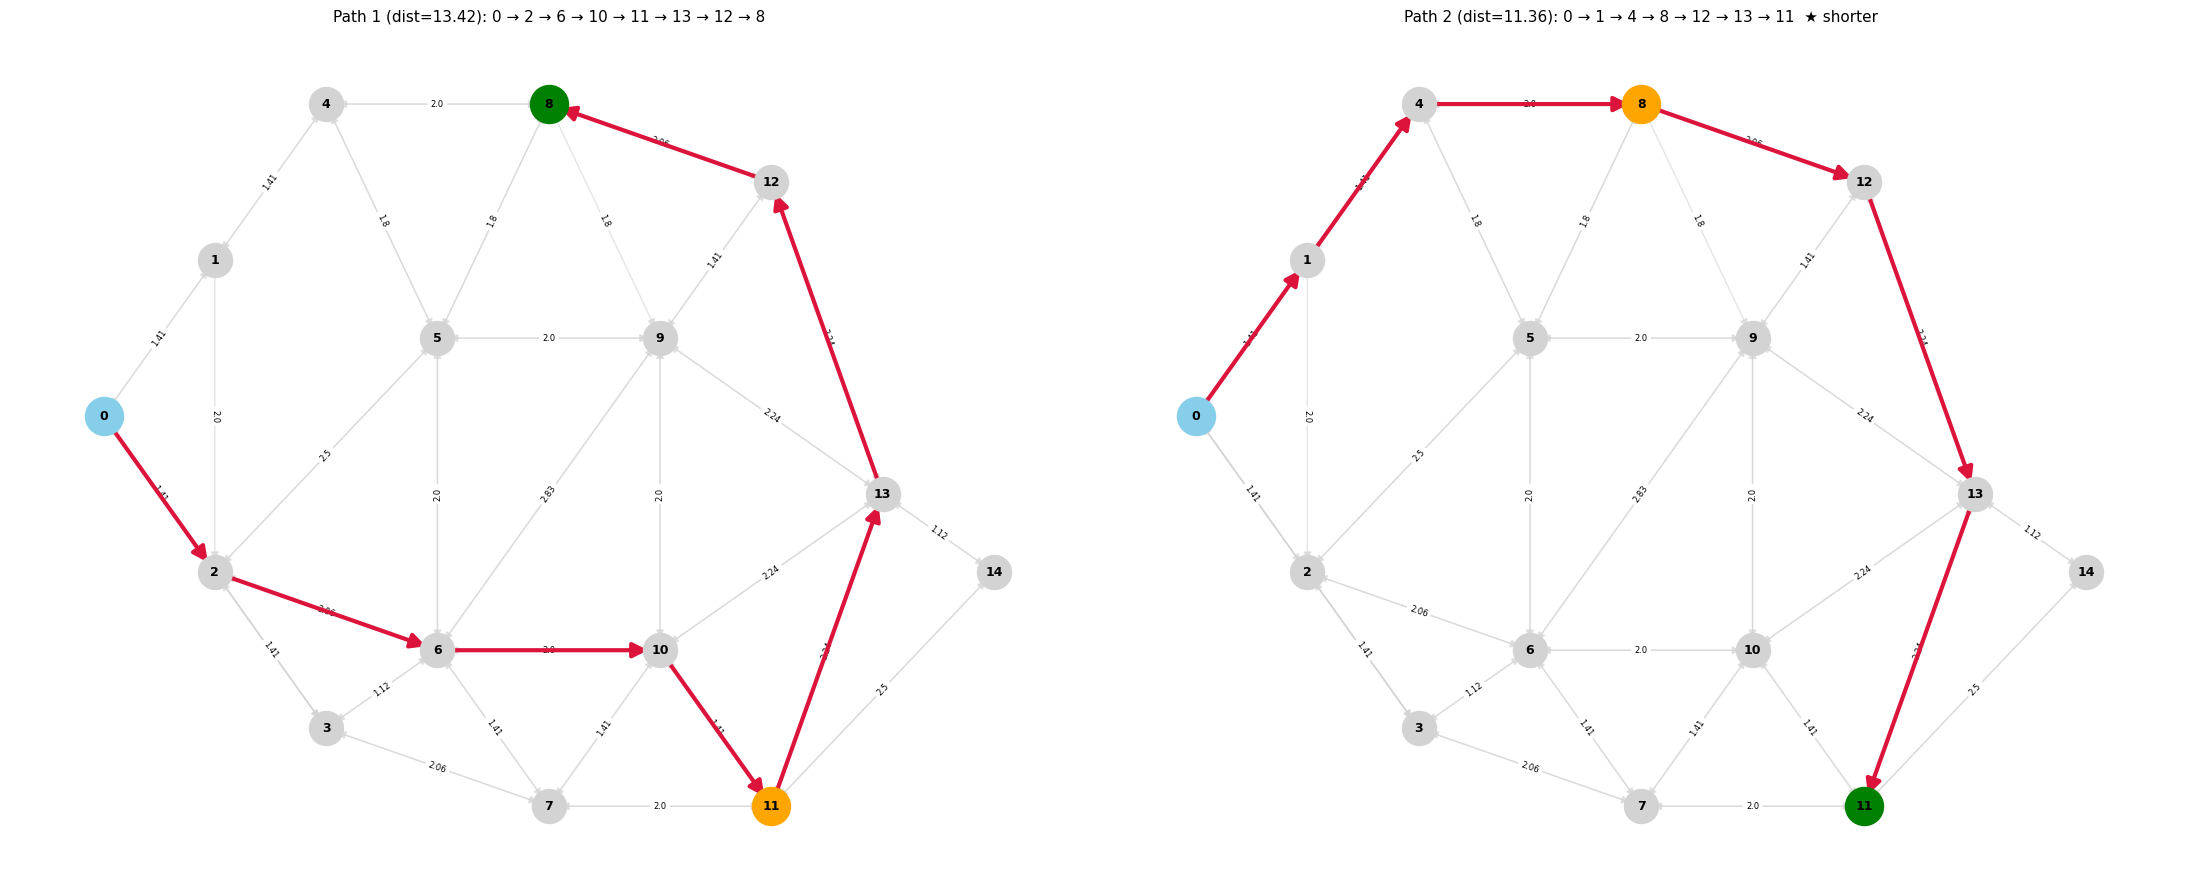

In [26]:
import matplotlib.pyplot as plt

# --- 1. Compute both greedy rollouts ---
def get_greedy_paths(model, G, start, target_1, target_2, num_nodes, num_goals, max_steps=30):

    def greedy_rollout(goal_a, goal_b, max_steps=30):
        path = [start]
        current_node = start
        current_target = goal_a
        steps = 0
        visited_states = {(current_node, current_target)}
        stuck = False

        while steps < max_steps:
            neighbors = list(G.successors(current_node))
            if not neighbors:
                break

            state_tensor = state_to_tensor(current_node, current_target, num_nodes)
            with torch.no_grad():
                q_values = model(state_tensor)[0]
                neighbor_q = {n: q_values[n].item() for n in neighbors}
                next_node = max(neighbor_q, key=neighbor_q.get)

            path.append(next_node)

            if next_node == current_target == goal_a:
                current_target = goal_b
            elif next_node == current_target == goal_b:
                break

            current_node = next_node
            steps += 1

            state_key = (current_node, current_target)
            if state_key in visited_states:
                stuck = True
                break
            visited_states.add(state_key)

        return path, stuck

    def path_cost(path):
        return sum(G[u][v]['weight'] for u, v in zip(path[:-1], path[1:]))

    path_1, stuck_1 = greedy_rollout(target_1, target_2)
    path_2, stuck_2 = greedy_rollout(target_2, target_1)

    return path_1, path_2, path_cost(path_1), path_cost(path_2), stuck_1, stuck_2


path_1, path_2, cost_1, cost_2, stuck_1, stuck_2 = get_greedy_paths(
    model, G, 0, target_1, target_2, num_nodes, num_goals
)

print(f"Path 1 (target_1 → target_2): {path_1}")
print(f"  Total real distance: {round(cost_1, 2)}" + ("  [STUCK IN LOOP]" if stuck_1 else ""))
print(f"Path 2 (target_2 → target_1): {path_2}")
print(f"  Total real distance: {round(cost_2, 2)}" + ("  [STUCK IN LOOP]" if stuck_2 else ""))

shorter = "Path 1" if cost_1 <= cost_2 else "Path 2"
print(f"\n{shorter} is shorter.")

# --- 2. Draw both graphs side by side ---
def draw_path_on_ax(ax, G, pos, path, target_1, target_2, title):
    nx.draw_networkx_nodes(G, pos, node_color="lightgray", node_size=600, ax=ax)
    nx.draw_networkx_edges(
        G, pos, edge_color="lightgray", arrows=True, arrowsize=12, width=1, alpha=0.6, ax=ax
    )
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax)

    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(
        G, pos, edgelist=path_edges,
        edge_color="crimson", width=3, arrows=True, arrowsize=22, ax=ax
    )

    special_colors = {0: "skyblue", target_1: "orange", target_2: "green"}
    for node, color in special_colors.items():
        nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color=color, node_size=750, ax=ax)

    ax.set_title(title, fontsize=11)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(22, 9))

draw_path_on_ax(
    axes[0], G, pos, path_1, target_1, target_2,
    f"Path 1 (dist={round(cost_1, 2)}): {' → '.join(map(str, path_1))}"
    + ("  ★ shorter" if cost_1 <= cost_2 else "")
)
draw_path_on_ax(
    axes[1], G, pos, path_2, target_2, target_1,
    f"Path 2 (dist={round(cost_2, 2)}): {' → '.join(map(str, path_2))}"
    + ("  ★ shorter" if cost_2 < cost_1 else "")
)

plt.tight_layout()
plt.show()

In [28]:
import networkx as nx

# Betweenness centrality — how often a node sits on shortest paths between others
# (good for finding "bridge" / bottleneck nodes)
betw_cent = nx.betweenness_centrality(G, weight='weight')

# Closeness centrality — how close a node is to all others (only meaningful if reachable)
close_cent = nx.closeness_centrality(G)

for name, scores in [
    ("Betweenness centrality", betw_cent),
    ("Closeness centrality", close_cent),
]:
    top_10 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"{name} — top 10:")
    for rank, (node, score) in enumerate(top_10, start=1):
        print(f"  {rank}. node {node}: {score:.4f}")
    print()

Betweenness centrality — top 10:
  1. node 6: 0.2509
  2. node 9: 0.1822
  3. node 5: 0.1699
  4. node 10: 0.1699
  5. node 2: 0.1593
  6. node 13: 0.1374
  7. node 4: 0.0879
  8. node 8: 0.0527
  9. node 1: 0.0495
  10. node 7: 0.0472

Closeness centrality — top 10:
  1. node 6: 0.6087
  2. node 9: 0.5833
  3. node 5: 0.5600
  4. node 10: 0.5385
  5. node 2: 0.5000
  6. node 7: 0.5000
  7. node 3: 0.4828
  8. node 13: 0.4667
  9. node 8: 0.4516
  10. node 12: 0.4516

